In [12]:
import sqlite3
import pandas as pd 
import matplotlib.pyplot as plt

con=sqlite3.connect(r'C:\Users\Scalefusion admin\OneDrive\Documents\OJT- SEM 3\project_3.1 sem 3\data\raw\ipl.db')
def q(sql):
    return pd.read_sql(sql, con)

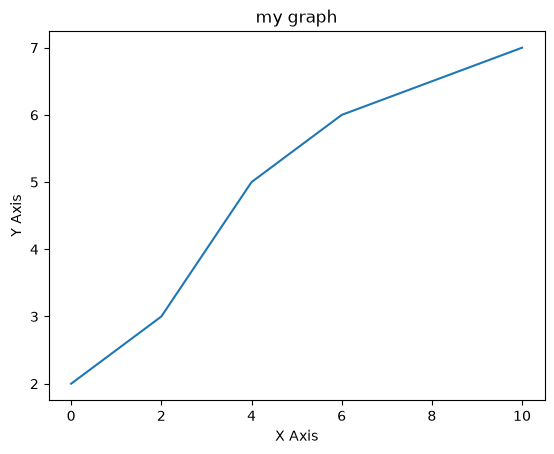

In [13]:
x= [0,2,4,6,10]
y=[2,3,5,6,7]

plt.plot(x,y)
plt.title("my graph")
plt.xlabel("X Axis")
plt.ylabel("Y Axis")
plt.show()

<Axes: title={'center': 'Total balls in Each phases'}, xlabel='different phases of innings', ylabel='total number of balls'>

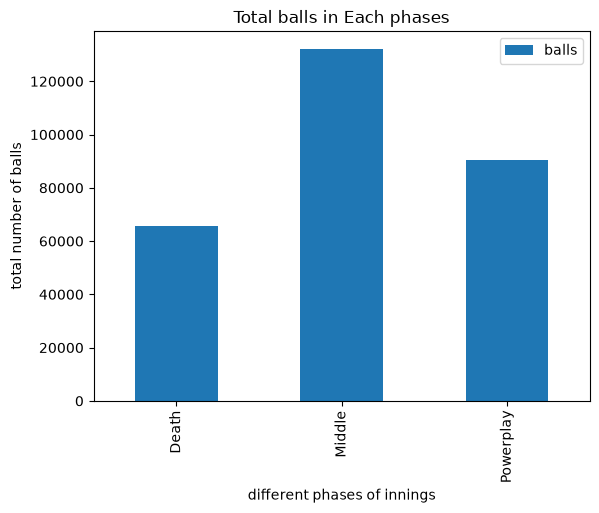

In [19]:
df=pd.read_sql("""SELECT phase, COUNT(*) AS balls FROM v_ball GROUP BY phase; """,con)
df.plot(kind="bar",
        x="phase",
        y="balls",
        title="Total balls in Each phases",
        xlabel="different phases of innings",
        ylabel="total number of balls")


In [17]:
q(""" 

-- list of Highest six scored in IPL History 

select batter ,
       SUM(CASE WHEN batter_runs=6
           THEN 1
           ELSE 0
           END) AS Total_sixes
FROM v_ball
GROUP BY batter
ORDER BY total_sixes DESC
LIMIT 5;""")

,batter,Total_sixes
0,CH Gayle,357
1,RG Sharma,311
2,V Kohli,307
3,MS Dhoni,264
4,AB de Villiers,251


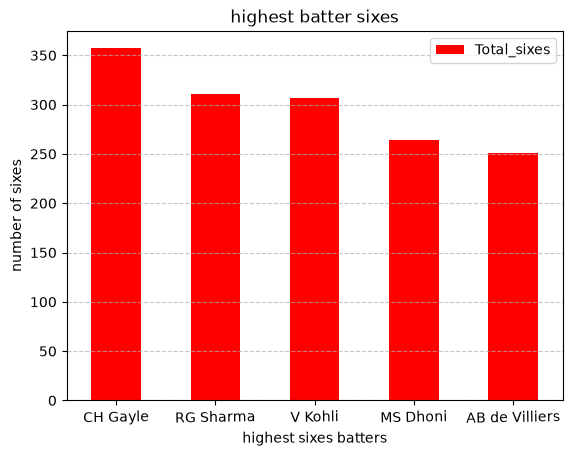

In [43]:
df=pd.read_sql("""select batter ,
       SUM(CASE WHEN batter_runs=6
           THEN 1
           ELSE 0
           END) AS Total_sixes
FROM v_ball
GROUP BY batter
ORDER BY total_sixes DESC
LIMIT 5; """,con)
df.plot(kind="bar",
        x="batter",
        y="Total_sixes",
        color="red",
        title="highest batter sixes",
        xlabel="highest sixes batters",
        ylabel="number of sixes")
plt.xticks(rotation=1)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

<Axes: title={'center': 'highest ball faced by a player'}, xlabel='total number of runs', ylabel='total number of balls'>

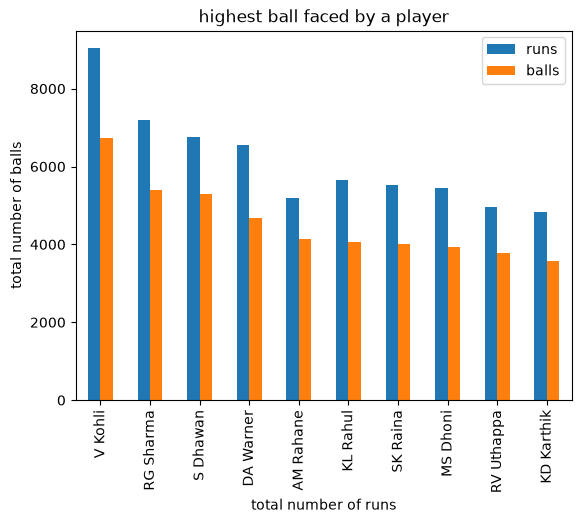

In [47]:
df=pd.read_sql("""SELECT batter,
            SUM(is_legal)  AS balls,
            SUM(batter_runs)AS runs,
            ROUND(100.0 * SUM (batter_runs)/SUM(is_legal),2) AS strike_rate

 FROM v_ball
 GROUP BY batter
 ORDER BY BALLS DESC
 LIMIT 10;
 """,con)
df.plot(kind="bar",
        x="batter",
        y=["runs","balls"],
        title="highest ball faced by a player",
        xlabel="total number of runs",
        ylabel="total number of balls")

In [49]:
q(""" 

--find an ideal middle-order batter who can lift the run rate in overs 7 to 15 

SELECT batter,sum(is_legal) AS balls,sum(batter_runs) AS runs,
              ROUND(100.0 * sum(batter_runs)/sum(is_legal),2) AS run_rate
            
        
FROM v_ball
WHERE phase = 'Middle'
GROUP BY batter
HAVING balls > 500
ORDER BY run_rate DESC
LIMIT 5;""")

,batter,balls,runs,run_rate
0,V Sehwag,611,1062,173.81
1,RM Patidar,566,970,171.38
2,N Pooran,848,1351,159.32
3,H Klaasen,697,1099,157.68
4,CH Gayle,1285,2011,156.50


<Axes: title={'center': 'run rate of middle over'}, xlabel='total number of runs', ylabel='batters'>

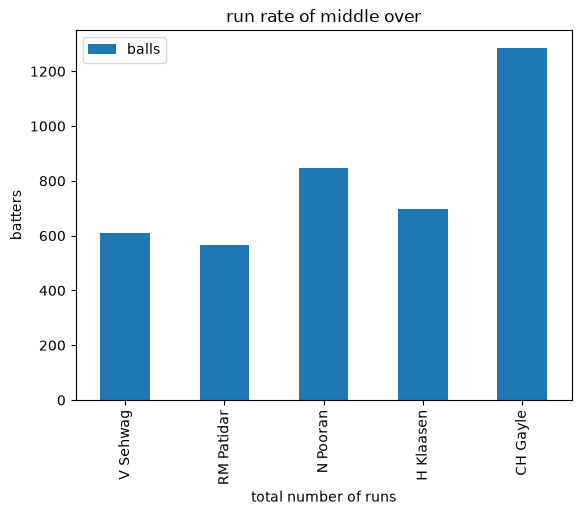

In [51]:
df=pd.read_sql("""SELECT batter,sum(is_legal) AS balls,sum(batter_runs) AS runs,
              ROUND(100.0 * sum(batter_runs)/sum(is_legal),2) AS run_rate
            
        
FROM v_ball
WHERE phase = 'Middle'
GROUP BY batter
HAVING balls > 500
ORDER BY run_rate DESC
LIMIT 5;""",con)
df.plot(kind="bar",
        x="batter",
        y="balls",
        title="run rate of middle over",
        xlabel="total number of runs",
        ylabel="batters")

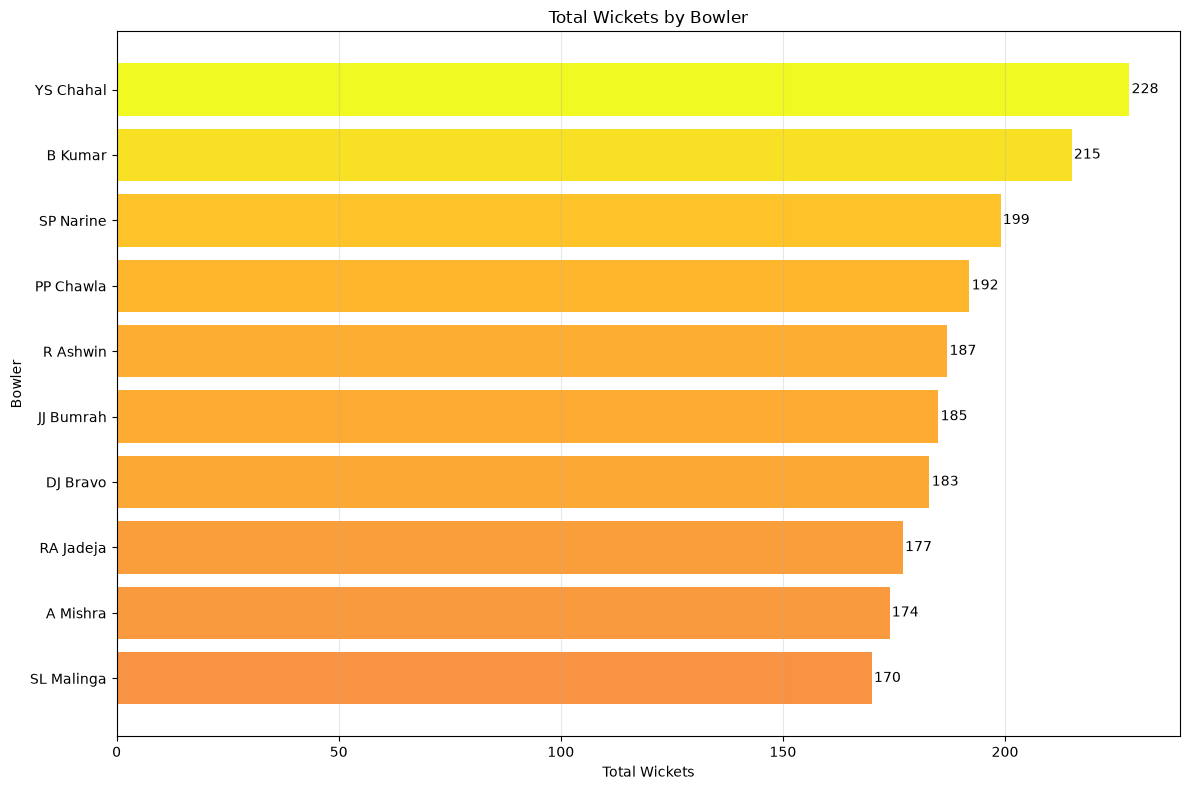

In [53]:
df= pd.read_sql("""
SELECT 
    bowler,
    SUM(bowler_wicket) AS wicket
FROM v_ball
GROUP BY bowler
ORDER BY wicket DESC limit 10;
""", con)

plt.figure(figsize=(12, 8))

colors = plt.cm.plasma(
    df["wicket"] / df["wicket"].max()
)

bars = plt.barh(
    df["bowler"],
    df["wicket"],
    color=colors
)

plt.xlabel("Total Wickets")
plt.ylabel("Bowler")
plt.title("Total Wickets by Bowler")

plt.gca().invert_yaxis()

# Add wicket values
for bar in bars:
    plt.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        int(bar.get_width()),
        va="center"
    )

plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

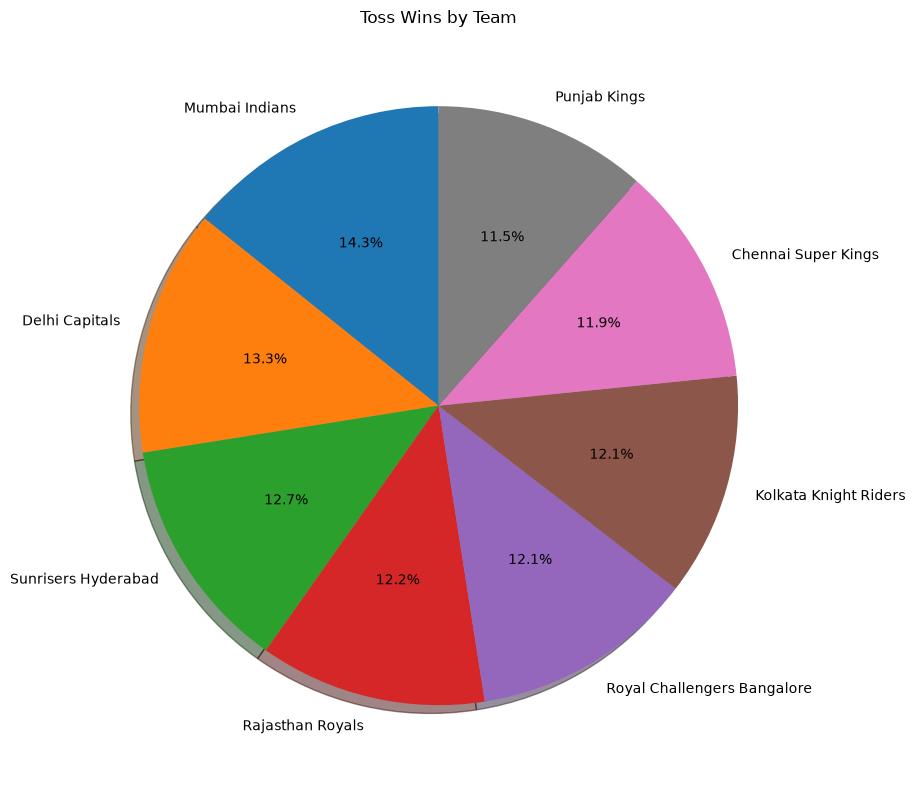

In [57]:
ag= pd.read_sql("""
SELECT
    toss_winner,
    COUNT(*) AS toss_won
FROM matches_clean
GROUP BY toss_winner
ORDER BY toss_won DESC limit 8;
""", con)

plt.figure(figsize=(10, 8))

plt.pie(
    ag["toss_won"],
    labels=ag["toss_winner"],
    autopct="%1.1f%%",
    startangle=90,
    shadow=True
)

plt.title("Toss Wins by Team")

plt.tight_layout()
plt.show()

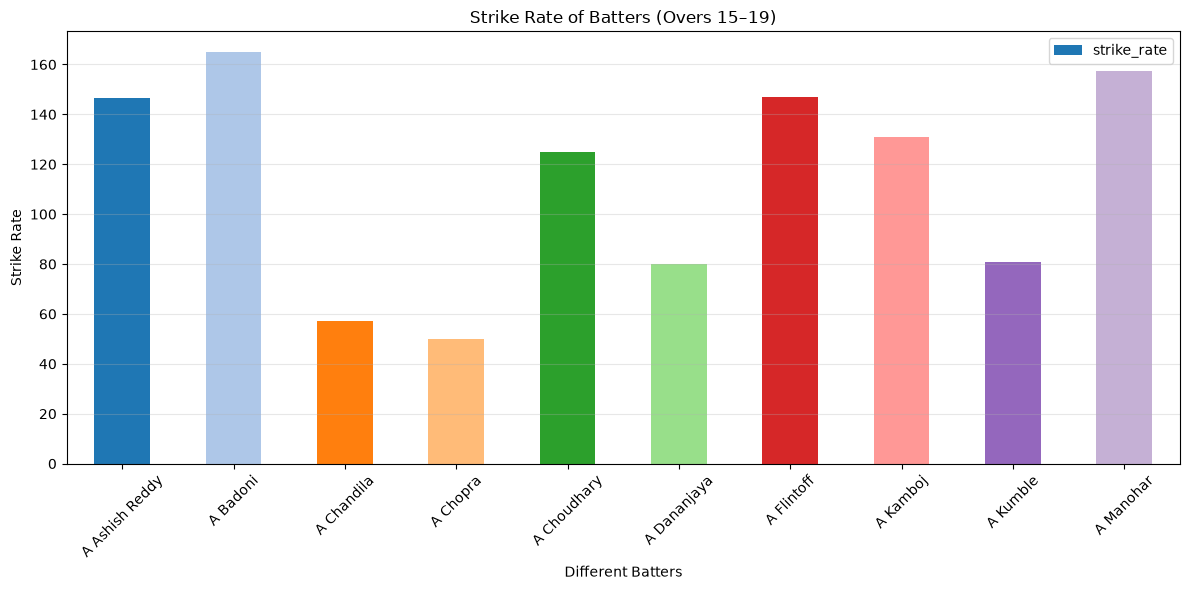

In [56]:
ab=pd.read_sql("""
SELECT 
    batter,
    ROUND(
        100.0 * SUM(batter_runs) / SUM(
            CASE
                WHEN is_wide_ball = 0 AND is_no_ball = 0
                THEN 1
                ELSE 0
            END
        ), 2
    ) AS strike_rate
FROM deliveries
WHERE over_number BETWEEN 15 AND 19
  AND is_super_over = 0
GROUP BY batter limit 10""",con)

colors = plt.cm.tab20(range(len(ab)))

ab.plot(
    kind="bar",
    x="batter",
    y="strike_rate",
    title="Strike Rate of Batters (Overs 15–19)",
    xlabel="Different Batters",
    ylabel="Strike Rate",
    color=colors,
    figsize=(12, 6)
)
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()